In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [59]:
df = pd.read_csv('/kaggle/input/user-churn/User churn.csv')

In [60]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [62]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [63]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [64]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

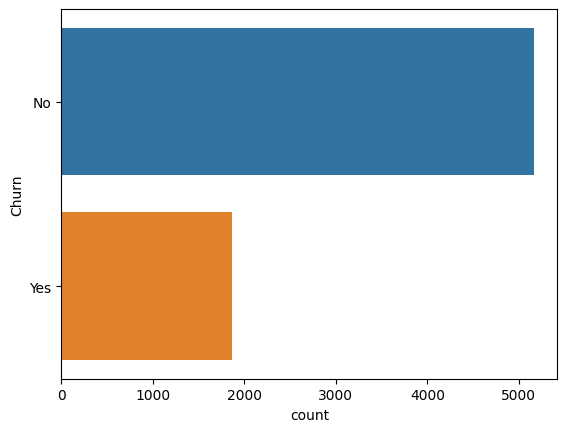

In [65]:
sns.countplot(data=df, y='Churn');

<Axes: xlabel='Churn', ylabel='TotalCharges'>

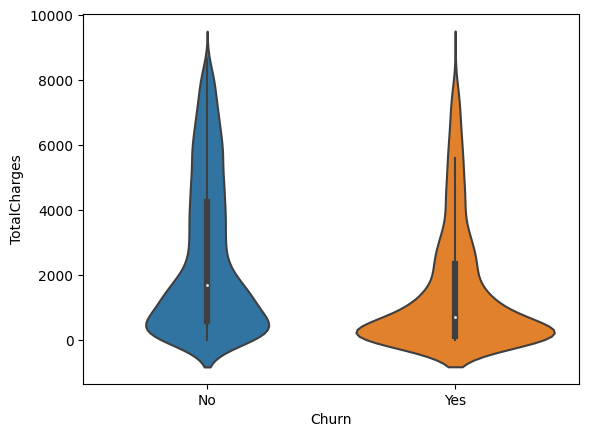

In [66]:
sns.violinplot(data=df,x='Churn',y='TotalCharges')

<Axes: xlabel='Churn', ylabel='TotalCharges'>

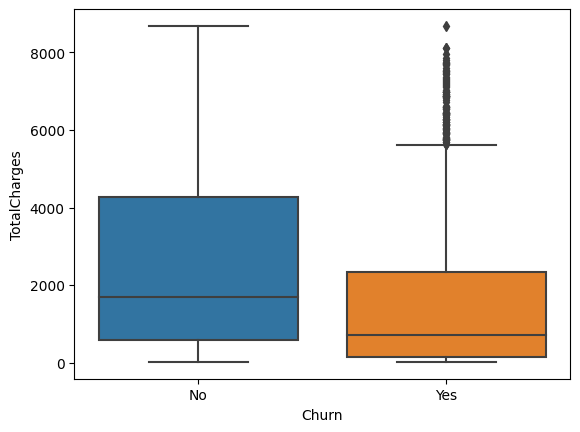

In [67]:
sns.boxplot(data=df,x='Churn',y='TotalCharges')

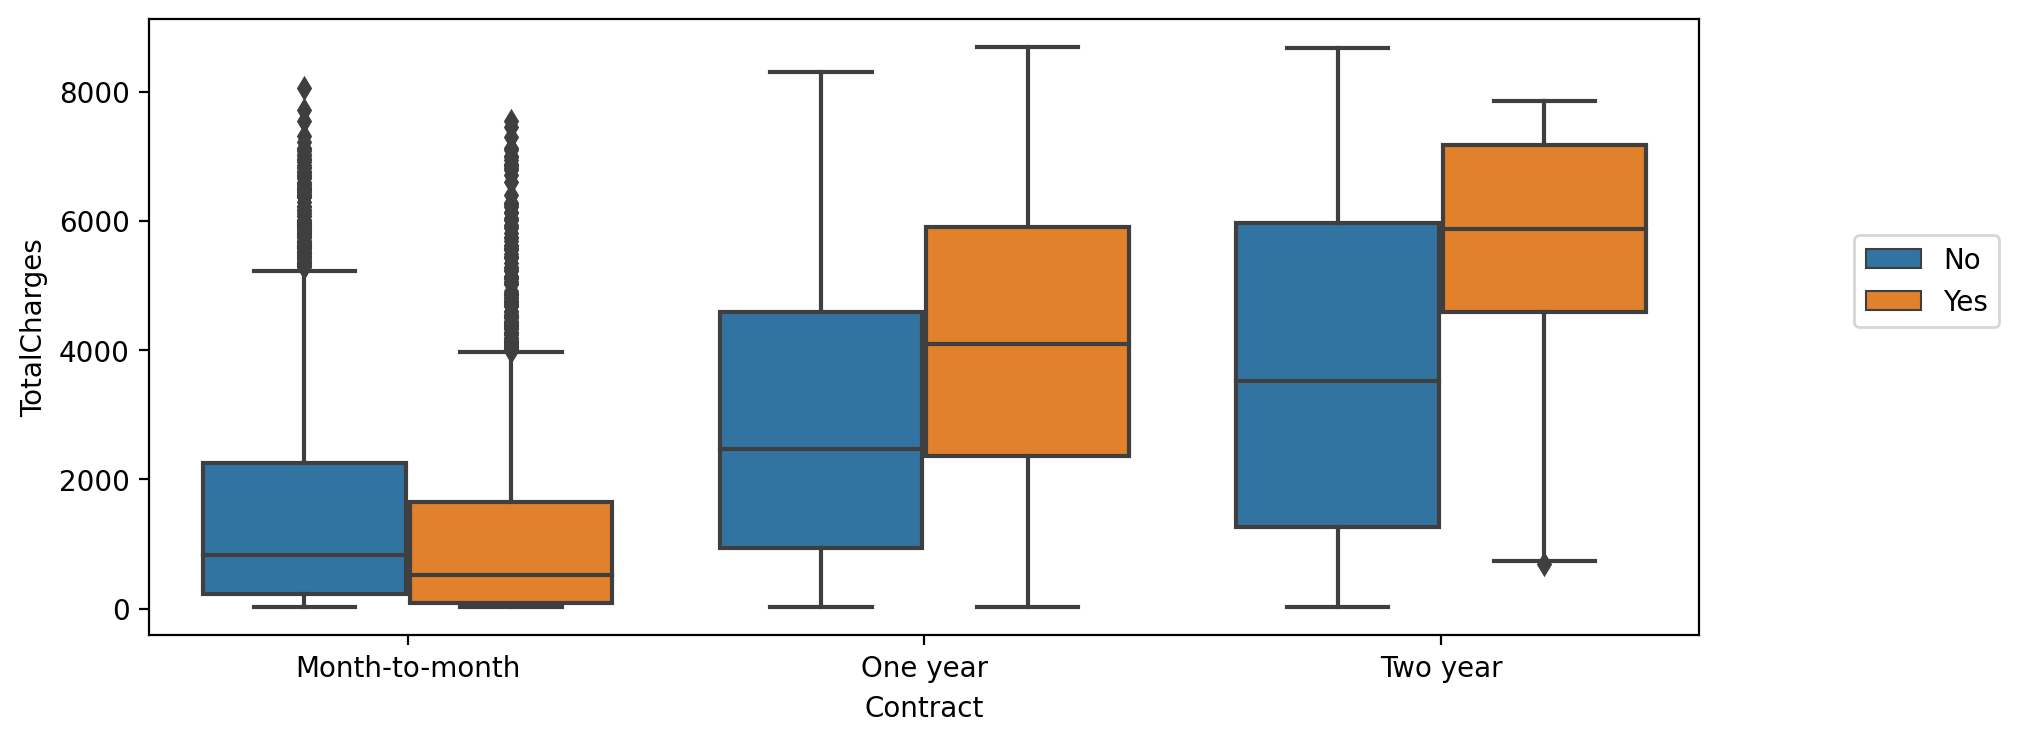

In [68]:
plt.figure(figsize=(10,4),dpi=200)
sns.boxplot(data=df,y='TotalCharges',x='Contract',hue='Churn')
plt.legend(loc=(1.1,0.5))

In [69]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [70]:
corr_df=pd.get_dummies(df[['gender','SeniorCitizen','Partner','Dependents','PhoneService',
                          'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
                          'TechSupport','InternetService','StreamingTV','StreamingMovies',
                           'Contract','PaperlessBilling','PaymentMethod','Churn']],dtype=int).corr()

pd.get_dummies converts categorical(gender,seniorcitizen,etc) variables into binary columns for machine learning


**The .corr() computes all pairwise correlations among every dummy column, including between the dummies themselves and between each dummy and the target (Churn).**

In [71]:
corr_df.head(4)

,SeniorCitizen,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
SeniorCitizen,1.000000,0.001819,-0.001819,-0.016957,0.016957,0.210550,-0.210550,-0.008392,0.008392,-0.136377,...,-0.046491,-0.116205,-0.156258,0.156258,-0.016235,-0.024359,0.171322,-0.152987,-0.150541,0.150541
gender_Female,0.001819,1.000000,-1.000000,-0.001379,0.001379,0.010349,-0.010349,-0.007515,0.007515,-0.004335,...,-0.007755,0.003603,-0.011902,0.011902,0.015973,-0.001632,-0.000844,-0.013199,-0.008545,0.008545
gender_Male,-0.001819,-1.000000,1.000000,0.001379,-0.001379,-0.010349,0.010349,0.007515,-0.007515,0.004335,...,0.007755,-0.003603,0.011902,-0.011902,-0.015973,0.001632,0.000844,0.013199,0.008545,-0.008545
Partner_No,-0.016957,-0.001379,0.001379,1.000000,-1.000000,0.452269,-0.452269,0.018397,-0.018397,0.130028,...,-0.083067,-0.247334,-0.013957,0.013957,-0.111406,-0.082327,0.083207,0.096948,-0.149982,0.149982


In [72]:
corr_yes_churn=corr_df['Churn_Yes'].sort_values().iloc[1:-1]

#t drops the first row (smallest correlation) and the last row (largest correlation), and returns all remaining rows in between

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41]),
 [Text(0, 0, 'Contract_Two year'),
  Text(1, 0, 'DeviceProtection_No internet service'),
  Text(2, 0, 'StreamingMovies_No internet service'),
  Text(3, 0, 'StreamingTV_No internet service'),
  Text(4, 0, 'InternetService_No'),
  Text(5, 0, 'TechSupport_No internet service'),
  Text(6, 0, 'OnlineBackup_No internet service'),
  Text(7, 0, 'OnlineSecurity_No internet service'),
  Text(8, 0, 'PaperlessBilling_No'),
  Text(9, 0, 'Contract_One year'),
  Text(10, 0, 'OnlineSecurity_Yes'),
  Text(11, 0, 'TechSupport_Yes'),
  Text(12, 0, 'Dependents_Yes'),
  Text(13, 0, 'Partner_Yes'),
  Text(14, 0, 'PaymentMethod_Credit card (automatic)'),
  Text(15, 0, 'InternetService_DSL'),
  Text(16, 0, 'PaymentMethod_Bank transfer (automatic)'),
  Text(17, 0, 'PaymentMethod_Mailed check'),
  Text(18, 0, 'OnlineBack

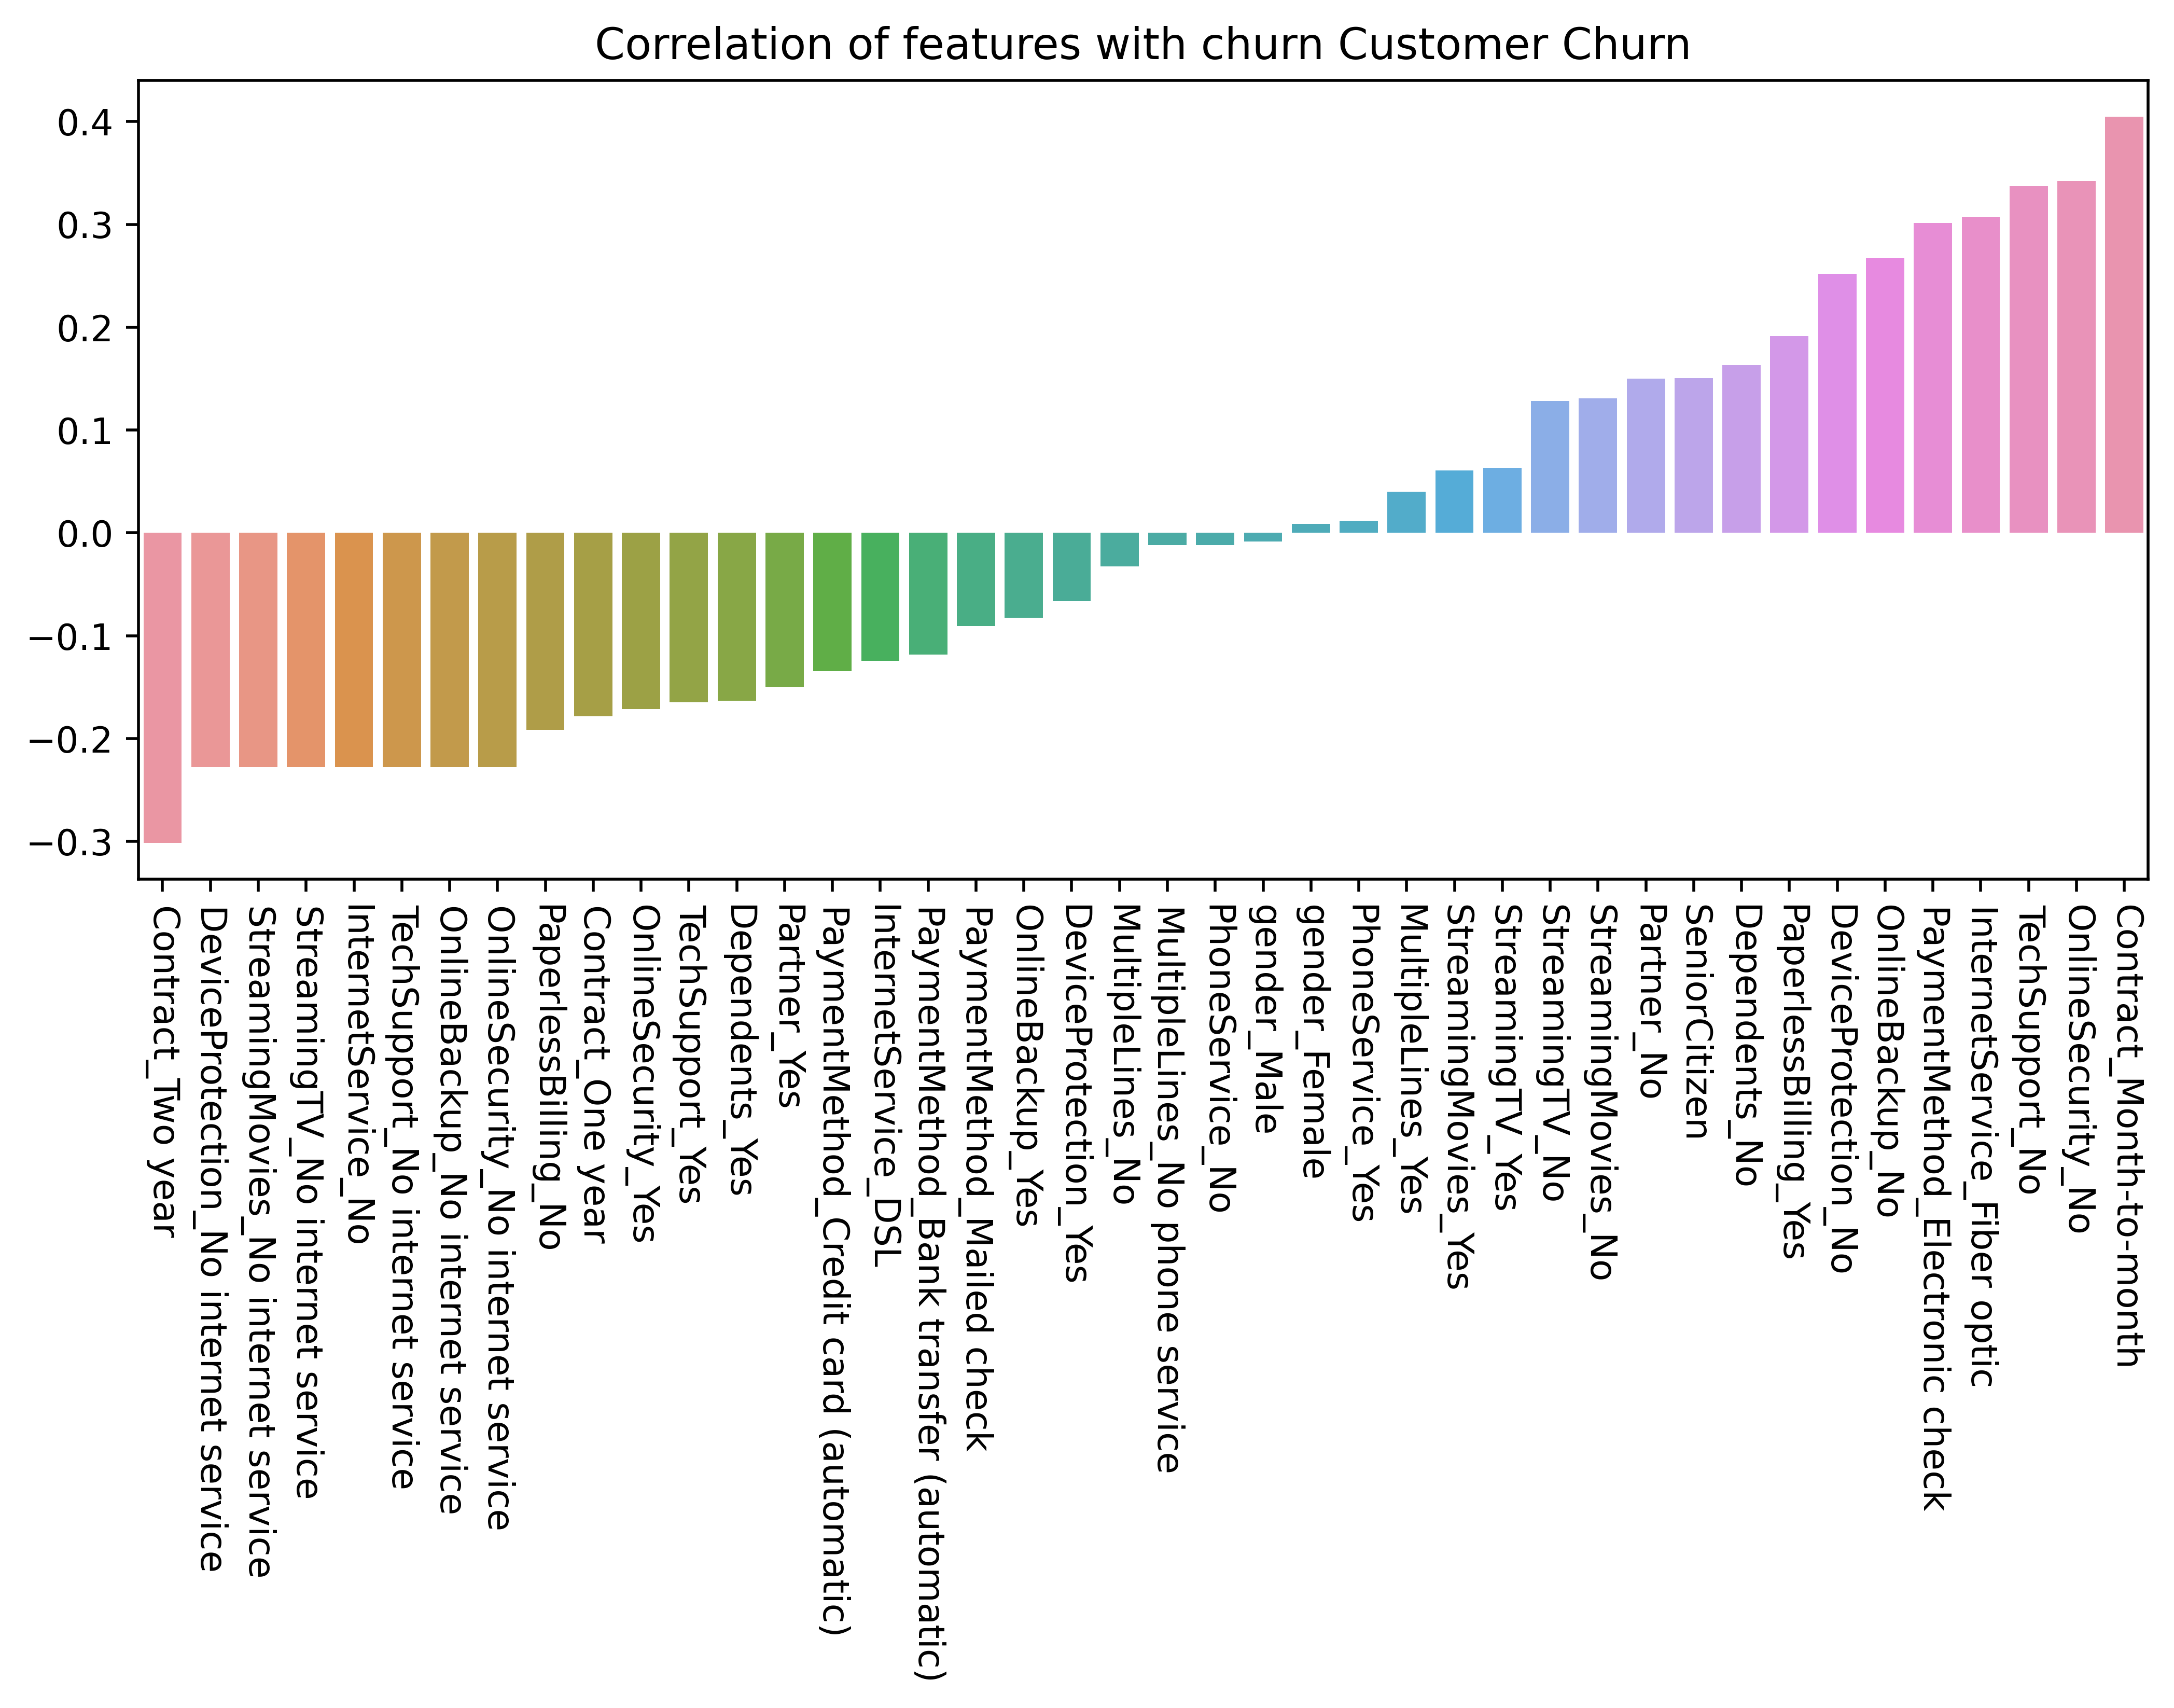

In [73]:
plt.figure(figsize=(10,4),dpi=500)
sns.barplot(x=corr_yes_churn.index, y=corr_yes_churn.values)
plt.title('Correlation of features with churn Customer Churn')
plt.xticks(rotation=-90)

In [74]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [75]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26, 39])

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='tenure', ylabel='Count'>

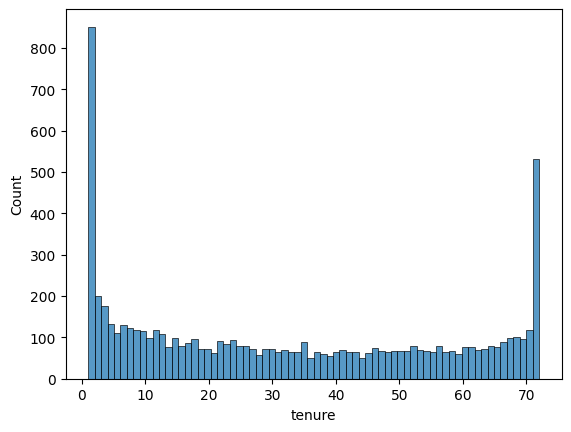

In [76]:
sns.histplot(data=df,x='tenure',bins=70)

tenure is the number of months a customer has been with the company (length of subscription/relationship).

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


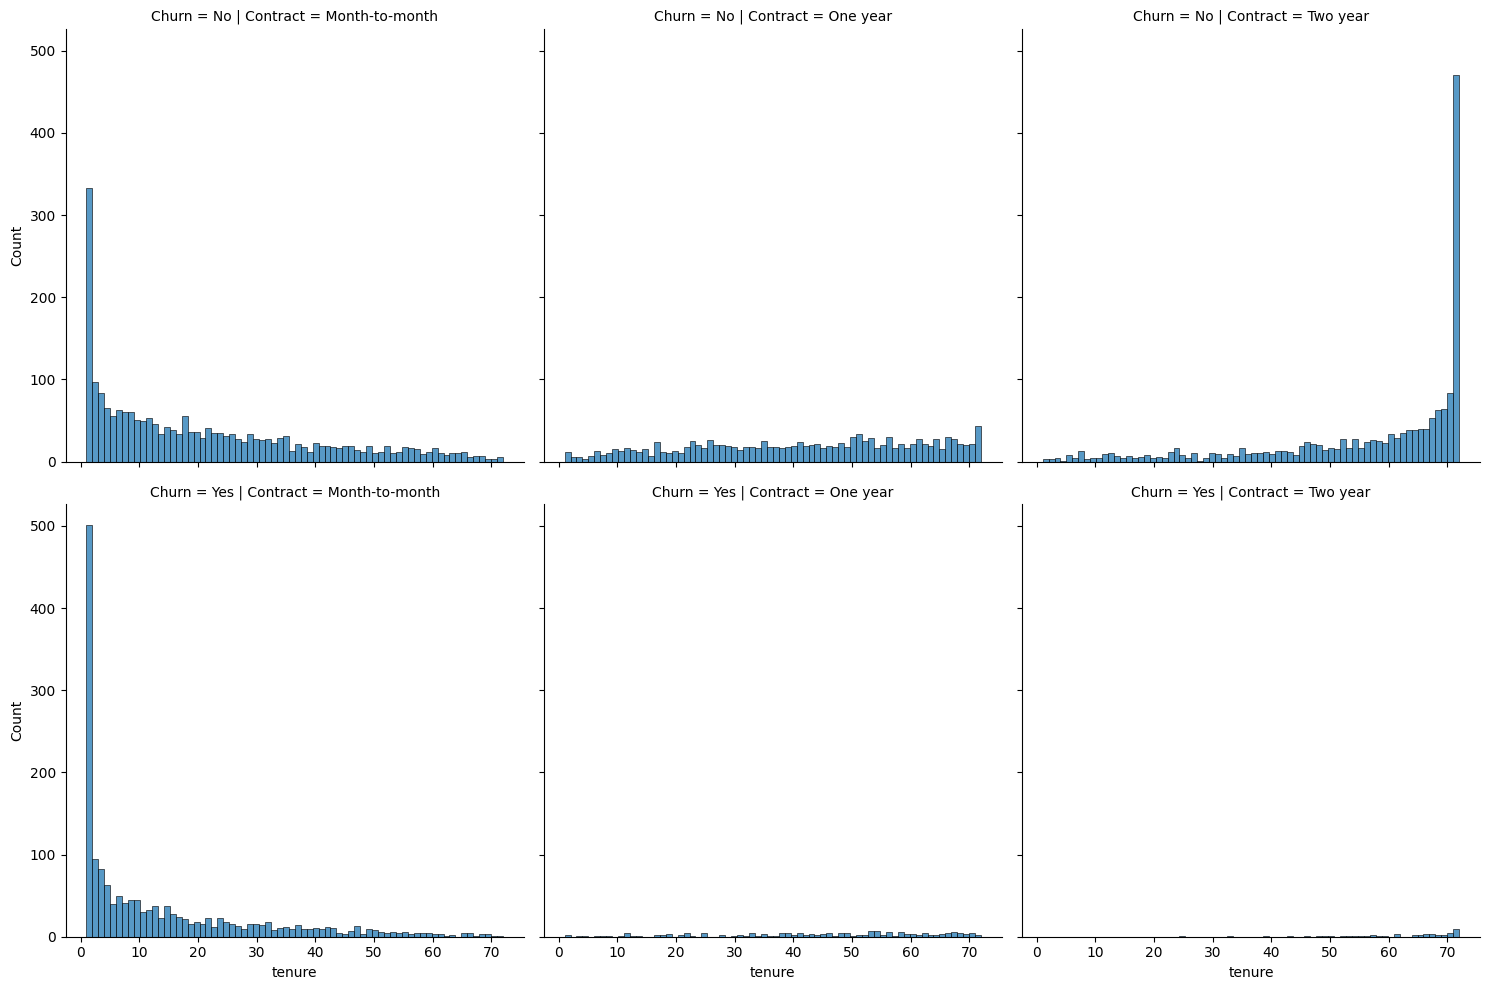

In [77]:
sns.displot(data=df,x='tenure',bins=70,col='Contract',row='Churn')

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

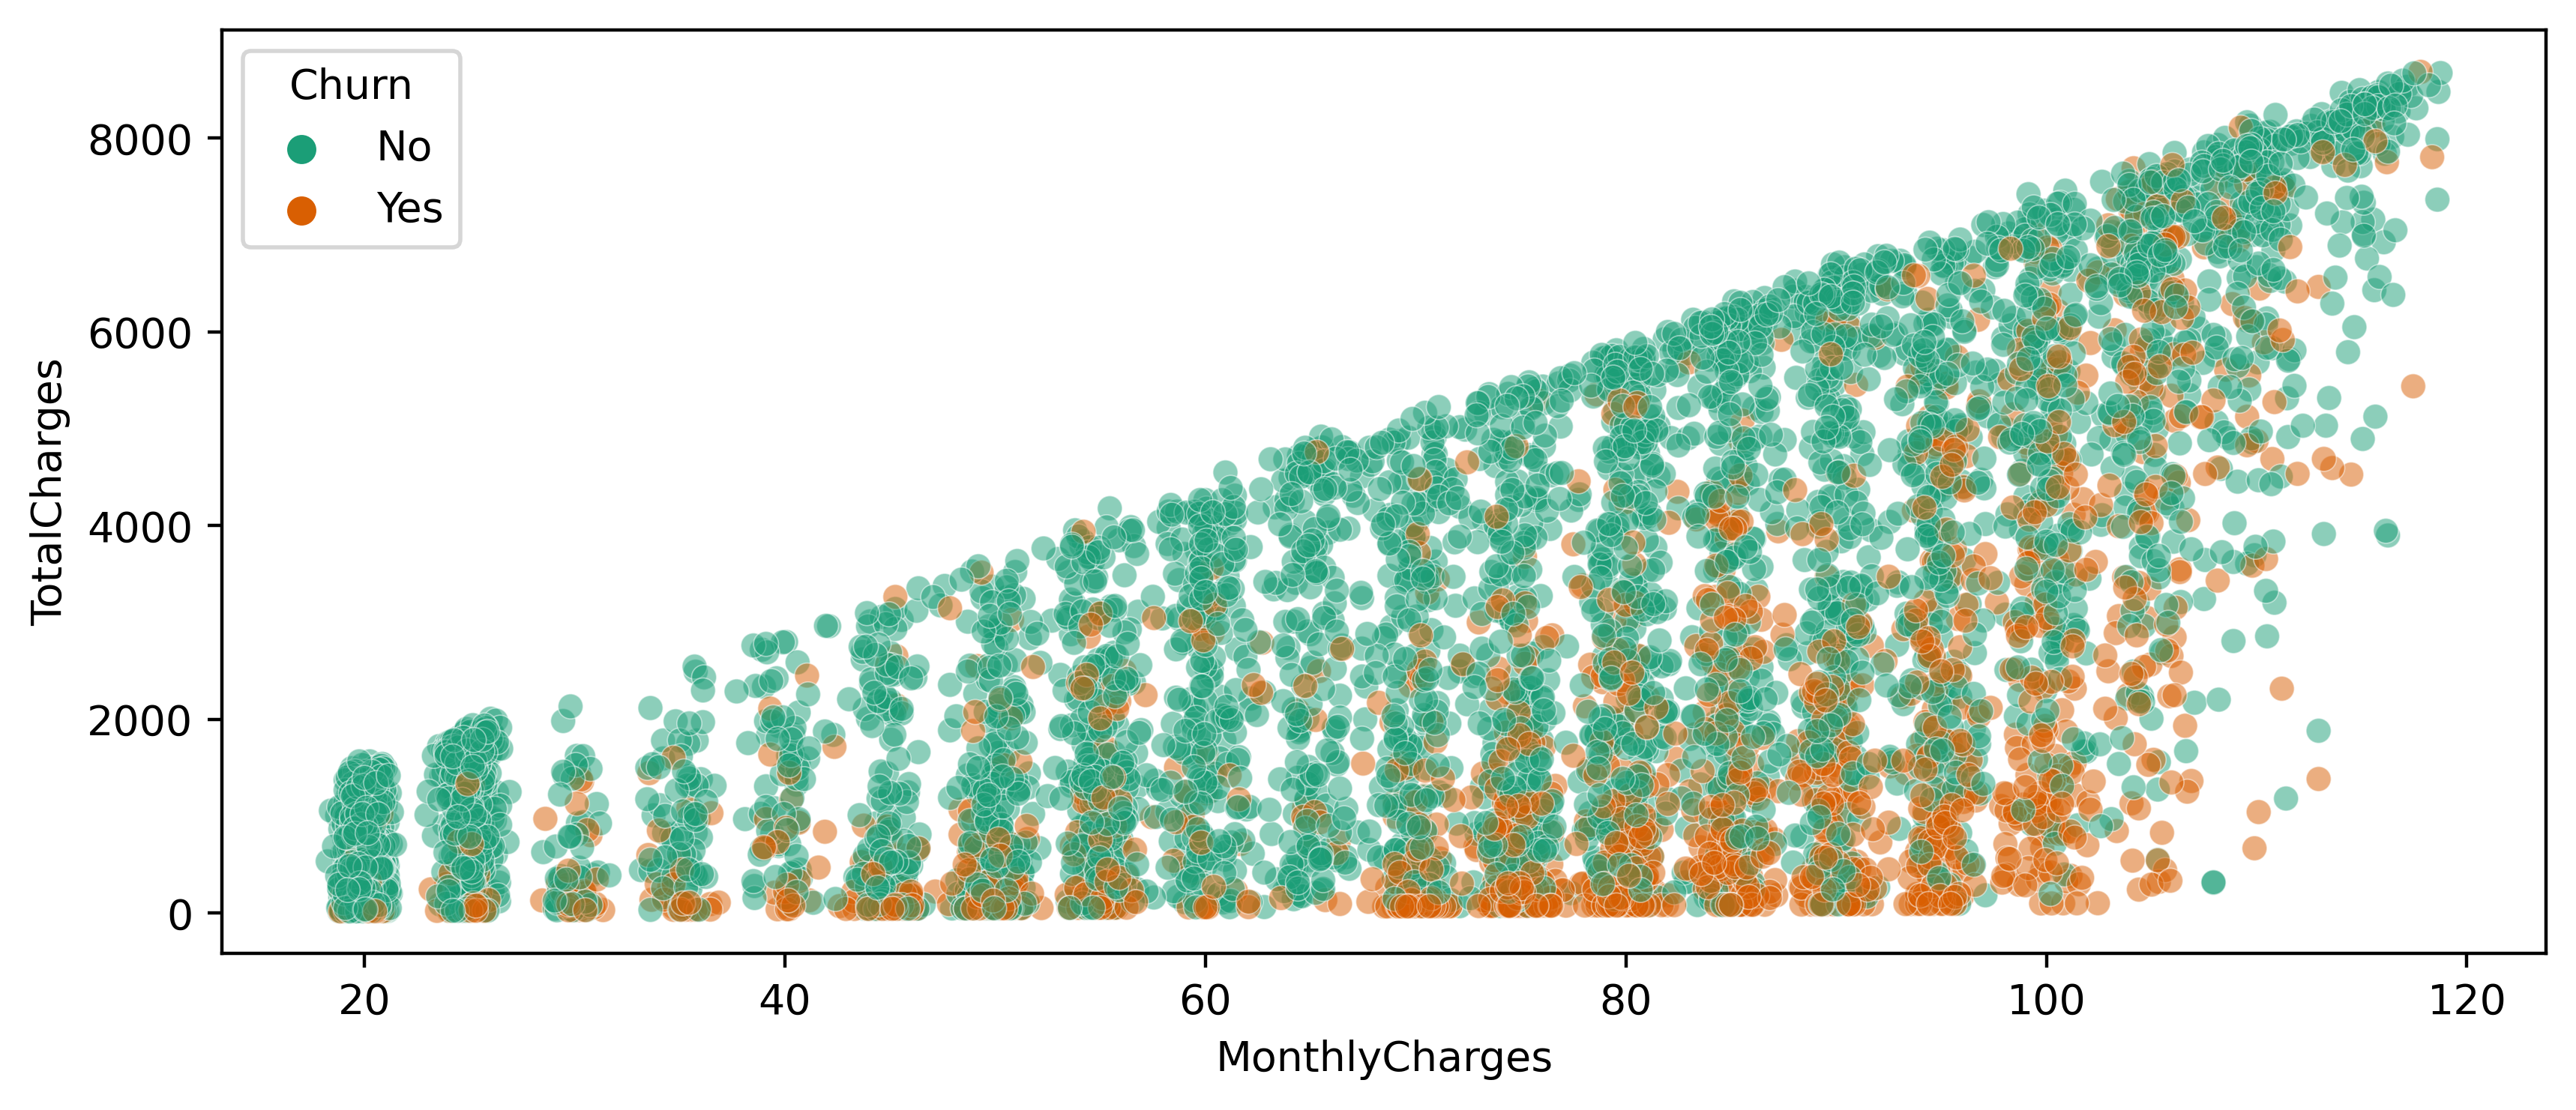

In [78]:
plt.figure(figsize=(10,4),dpi=400)
sns.scatterplot(data=df,x='MonthlyCharges',y='TotalCharges',hue='Churn',alpha=0.5,linewidth=0.3,palette='Dark2')

High monthly cost + short customer tenure associated with churn.

In [79]:
yes_churn = df.groupby(['Churn', 'tenure']).count().transpose()['Yes']
no_churn = df.groupby(['Churn', 'tenure']).count().transpose()['No']

In [80]:
yes_churn

tenure,1,2,3,4,5,6,7,8,9,10,...,63,64,65,66,67,68,69,70,71,72
customerID,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
gender,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
SeniorCitizen,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
Partner,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
Dependents,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
PhoneService,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
MultipleLines,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
InternetService,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
OnlineSecurity,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
OnlineBackup,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6


From yes_churn, you can see:

Which tenure values have the highest number of churned customers.

Easily, we can interpret that the first month have the most churned customers,as tenure value increases the churn decreases.

In [81]:
no_churn

tenure,1,2,3,4,5,6,7,8,9,10,...,63,64,65,66,67,68,69,70,71,72
customerID,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
gender,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
SeniorCitizen,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
Partner,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
Dependents,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
PhoneService,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
MultipleLines,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
InternetService,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
OnlineSecurity,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356
OnlineBackup,233,115,106,93,69,70,80,81,73,71,...,68,76,67,76,88,91,87,108,164,356


In [82]:
churn_rate=100*yes_churn/(no_churn+yes_churn)
churn_rate.transpose()['customerID']

tenure
1     61.990212
2     51.680672
3     47.000000
4     47.159091
5     48.120301
        ...    
68     9.000000
69     8.421053
70     9.243697
71     3.529412
72     1.657459
Name: customerID, Length: 72, dtype: float64

<Axes: xlabel='tenure'>

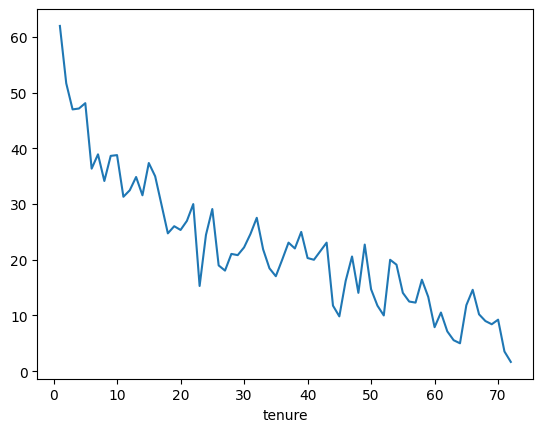

In [83]:
churn_rate.transpose()['customerID'].plot()

AS TENURE INCREASES CHURN RATE DECREASES


In [84]:
def group(tenure):
    if tenure < 13:
        return '0-12 months'
    elif tenure < 25:
        return '12-24 months'
    elif tenure < 49:
        return '24-48 months'
    else:
        return 'More than 48 months'

In [85]:
df['Tenure Cluster']=df['tenure'].apply(group)

In [86]:
df[['Tenure Cluster','tenure']]

,Tenure Cluster,tenure
0,0-12 months,1
1,24-48 months,34
2,0-12 months,2
3,24-48 months,45
4,0-12 months,2
...,...,...
7027,12-24 months,24
7028,More than 48 months,72
7029,0-12 months,11
7030,0-12 months,4


<Axes: xlabel='Tenure Cluster', ylabel='count'>

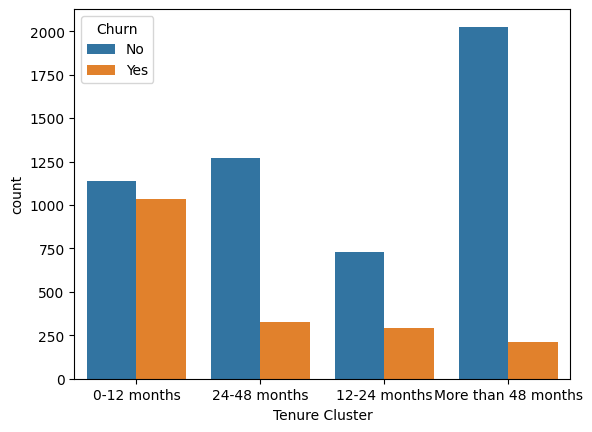

In [87]:
sns.countplot(data=df, x='Tenure Cluster', hue='Churn')

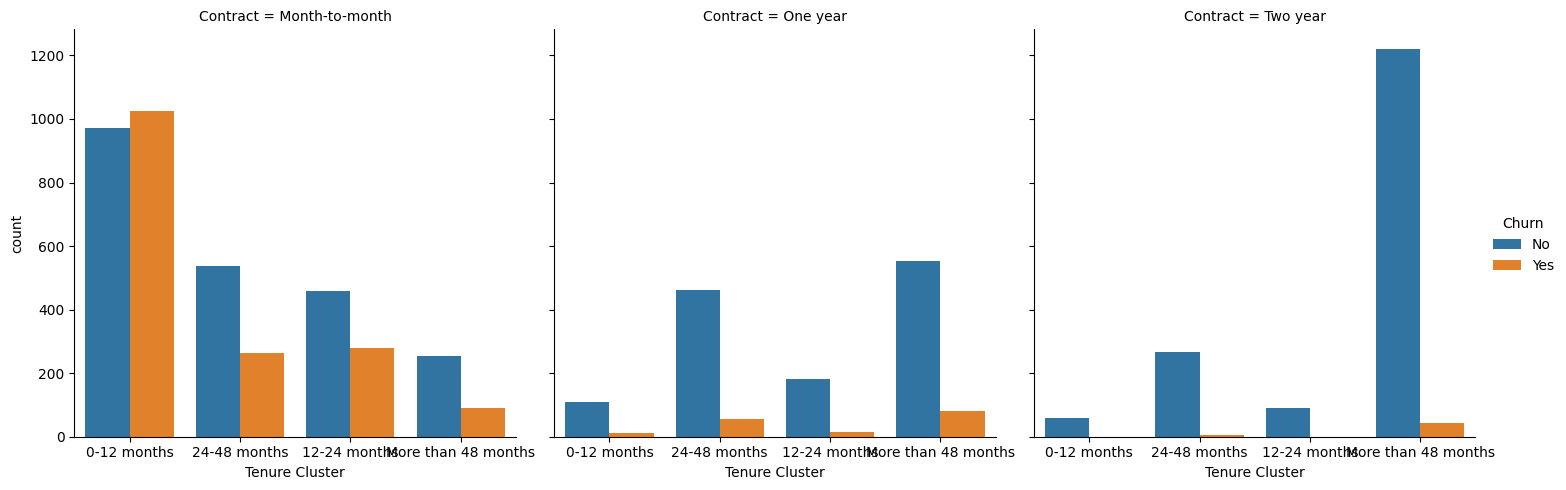

In [88]:
sns.catplot(data=df, x='Tenure Cluster', hue='Churn', kind='count', col='Contract');


In [89]:
X=df.drop(['Churn','customerID'],axis=1)
X=pd.get_dummies(X,drop_first=True)
y=df['Churn']

In [90]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

INSERTING SMOTE

In [91]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train, y_train)


In [92]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=6,random_state=42)
dt.fit(X_train_smote,y_train_smote)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [93]:
from sklearn.metrics import classification_report, confusion_matrix
pred=dt.predict(X_test)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

          No       0.86      0.78      0.82      1033
         Yes       0.52      0.65      0.58       374

    accuracy                           0.75      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.75      0.75      1407



The model only caught 65% of customers who actually churned.

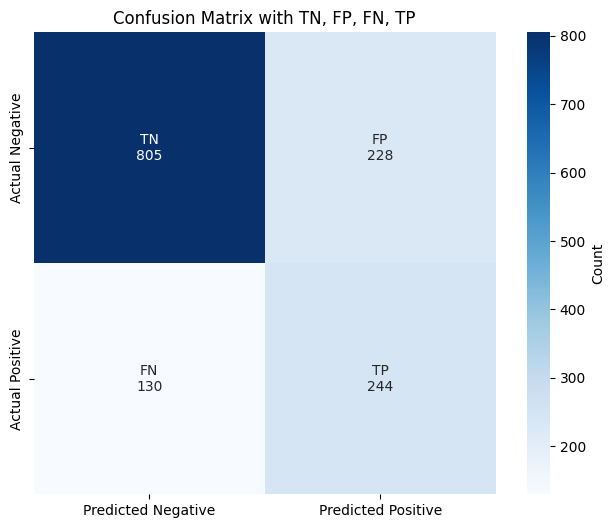

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

# Create annotations with labels
annotations = np.empty_like(cm, dtype='object')
annotations[0, 0] = f'TN\n{cm[0, 0]}'  # True Negative
annotations[0, 1] = f'FP\n{cm[0, 1]}'  # False Positive
annotations[1, 0] = f'FN\n{cm[1, 0]}'  # False Negative
annotations[1, 1] = f'TP\n{cm[1, 1]}'  # True Positive

# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=annotations, 
            fmt='', 
            cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'],
            cbar_kws={'label': 'Count'},
            square=True)
plt.title('Confusion Matrix with TN, FP, FN, TP')
plt.show()

AFTER SMOTE
(244)TP=CORRECTLY IDENTIFIES WHO LEFT.(CORRECTLY IDENTIFIED CUSTOMERS)(805)TN=PREDICTED STAY AND ACTUALLY STAYED.(LOYAL CUSTOMERS)(228)FP=PREDICTED CHURN BUT STAYED(WASTED EFFORTS)(130)FN=PREDICTED STAY BUT ACTUALLY CHURNED.(VERY BAD)

In [95]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(max_depth=6,random_state=42)
rf.fit(X_train_smote,y_train_smote)

RandomForestClassifier(max_depth=6, random_state=42)

In [96]:
pred=rf.predict(X_test)
print(classification_report(y_test,pred))


              precision    recall  f1-score   support

          No       0.89      0.76      0.82      1033
         Yes       0.53      0.75      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.75      0.77      1407



The model only caught 76% of customers who actually churned using random forest classifier.

In [107]:
joblib.dump(rf, '/kaggle/working/rf_model.joblib')
print("✅ RandomForest model saved successfully!")

✅ RandomForest model saved successfully!


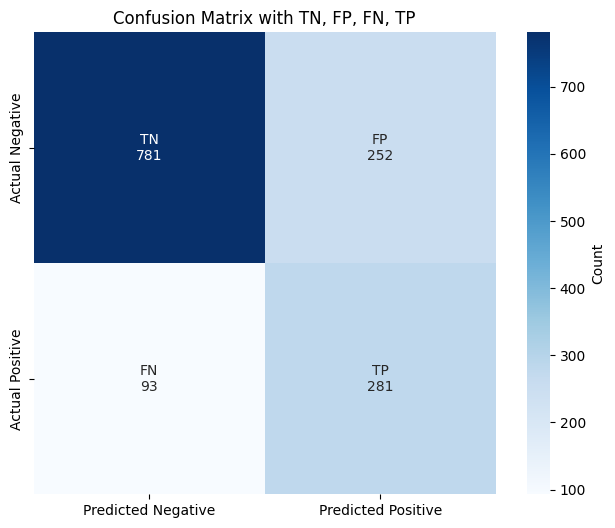

In [97]:
cm = confusion_matrix(y_test, pred)

# Create annotations with labels
annotations = np.empty_like(cm, dtype='object')
annotations[0, 0] = f'TN\n{cm[0, 0]}'  # True Negative
annotations[0, 1] = f'FP\n{cm[0, 1]}'  # False Positive
annotations[1, 0] = f'FN\n{cm[1, 0]}'  # False Negative
annotations[1, 1] = f'TP\n{cm[1, 1]}'  # True Positive

# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=annotations, 
            fmt='', 
            cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'],
            cbar_kws={'label': 'Count'},
            square=True)
plt.title('Confusion Matrix with TN, FP, FN, TP')
plt.show()


DUE TO IMBALANCE DATA GRADIENT BOOSTING ENSEMBLE MODEL LIKE XGBOOST OR LIGHTGBM CAN BE HELPFUL.

In [98]:
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier

gb_model=GradientBoostingClassifier(random_state=42)

In [99]:
gb_model.fit(X_train_smote,y_train_smote)

GradientBoostingClassifier(random_state=42)

In [100]:
gb_preds = gb_model.predict(X_test)

In [101]:
print(classification_report(y_test, gb_preds))


              precision    recall  f1-score   support

          No       0.87      0.80      0.83      1033
         Yes       0.55      0.68      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



In [102]:
model=AdaBoostClassifier(n_estimators=100,random_state=42)
model.fit(X_train_smote,y_train_smote)
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.87      0.79      0.83      1033
         Yes       0.54      0.67      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



In [103]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[820 213]
 [124 250]]


In [104]:
import joblib


model_data = {
    'model': model,
    'threshold': 0.40,
    
}

joblib.dump(model_data, 'churn_model.joblib')


['churn_model.joblib']

In [105]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = {
    'Decision Tree':        (dt,        X_train_smote, y_train_smote),
    'Random Forest':        (rf,        X_train_smote, y_train_smote),
    'Gradient Boosting':    (gb_model,  X_train_smote, y_train_smote),
    'AdaBoost (tuned)':     (model,     X_train_smote, y_train_smote),
}

results = []
for name, (clf, Xtr, ytr) in models.items():
    preds = clf.predict(X_test)
    report = classification_report(y_test, preds, output_dict=True)
    results.append({
        'Model':            name,
        'Accuracy':         round(report['accuracy'], 3),
        'Churn Precision':  round(report['Yes']['precision'], 3),
        'Churn Recall':     round(report['Yes']['recall'], 3),
        'Churn F1':         round(report['Yes']['f1-score'], 3),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                   Accuracy  Churn Precision  Churn Recall  Churn F1
Model                                                               
Decision Tree         0.746            0.517         0.652     0.577
Random Forest         0.755            0.527         0.751     0.620
Gradient Boosting     0.765            0.546         0.679     0.605
AdaBoost (tuned)      0.760            0.540         0.668     0.597


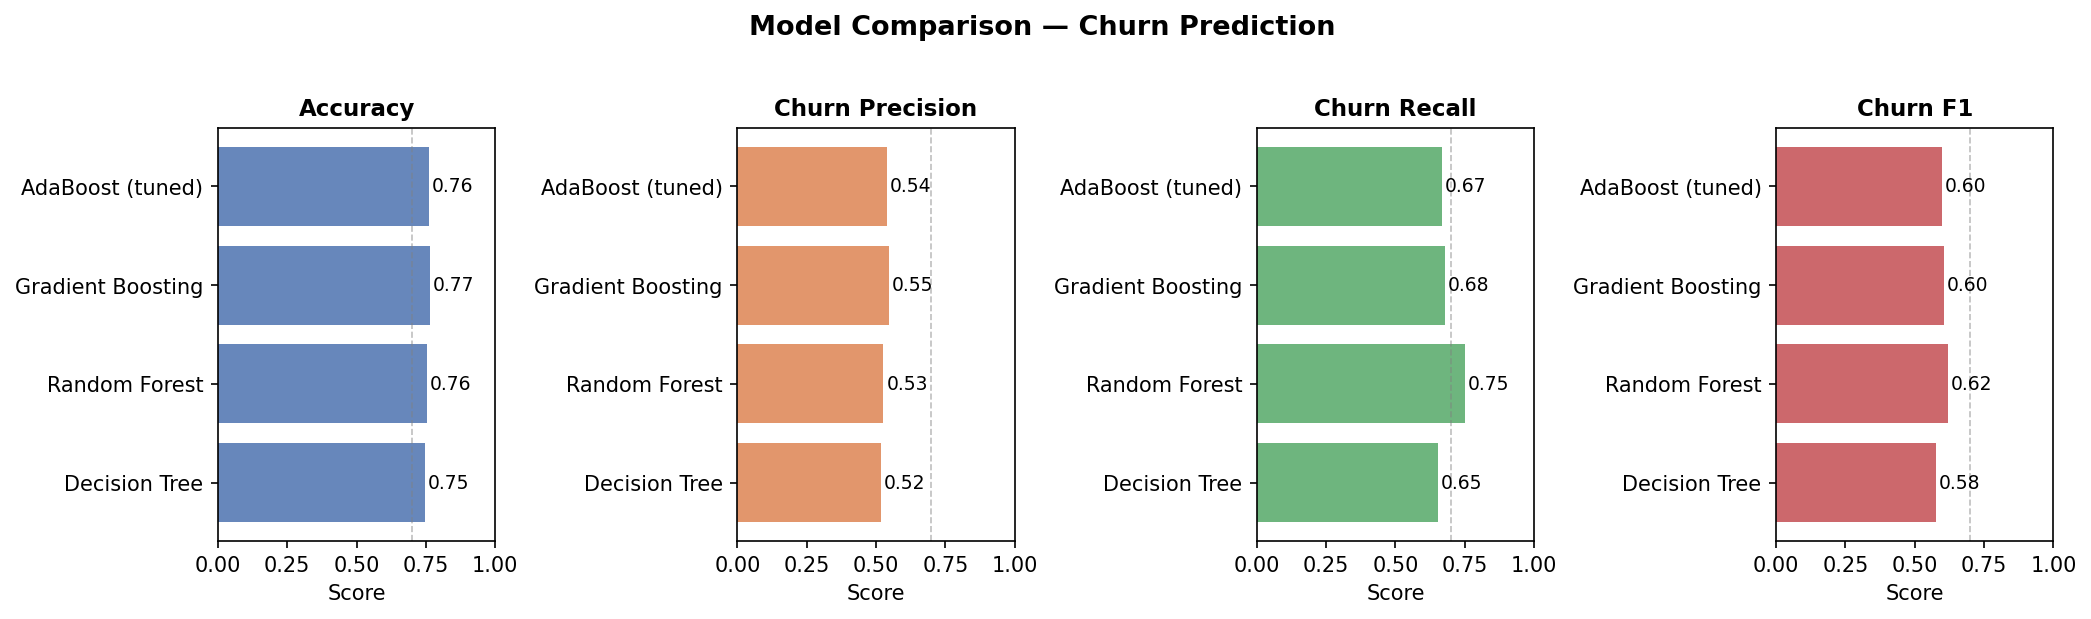


Best model: Random Forest with Recall = 75.1%


In [106]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), dpi=150)
metrics = ['Accuracy', 'Churn Precision', 'Churn Recall', 'Churn F1']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.barh(results_df.index, results_df[metric], color=color, alpha=0.85)
    ax.set_xlim(0, 1)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.axvline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)
    ax.set_xlabel('Score')

plt.suptitle('Model Comparison — Churn Prediction', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best = results_df['Churn Recall'].idxmax()
print(f"\nBest model: {best} with Recall = {results_df.loc[best, 'Churn Recall']:.1%}")